In [1]:
"""
Re‑creates your current world + camera demo and opens a matplotlib window.
Run:  python -m examples.demo_world
"""
import numpy as np
import torch

from nerflab import (
    Intrinsics, Camera, Box, Sphere, World, plot_world, CFG, pose_H, make_pose_cases, save_world, load_world, World, Box, Sphere
)
from nerflab.camera.presets import make_spherical_poses


In [2]:
world = load_world("../data/world.json")

## Uniform band around the object (avoid poles):

In [3]:
# build preset dictionary
HB = make_spherical_poses(c=100, radius=4.0, center=(0,0,0), lat_range_deg=(-75,75))

print(HB.shape)

torch.Size([100, 4, 4])


In [4]:
# for i in range(32):
#   print((HB[i][:3, 3]))
#   print((HB[i][:3, 3]**2).sum()**.5)

In [5]:
# --- camera ------------------------------------------------------------------
cam_batched   = Camera(HB)

# --- sample rays -------------------------------------------------------------
O_B, D_B = cam_batched.get_rays_sampled(frame="world", rays_per_pose=100)
tB, deltaB, ptsB = cam_batched.sample_along_rays(O_B, D_B, rng=torch.manual_seed(0))
print("points shape:", ptsB.shape)


points shape: torch.Size([100, 100, 40, 3])


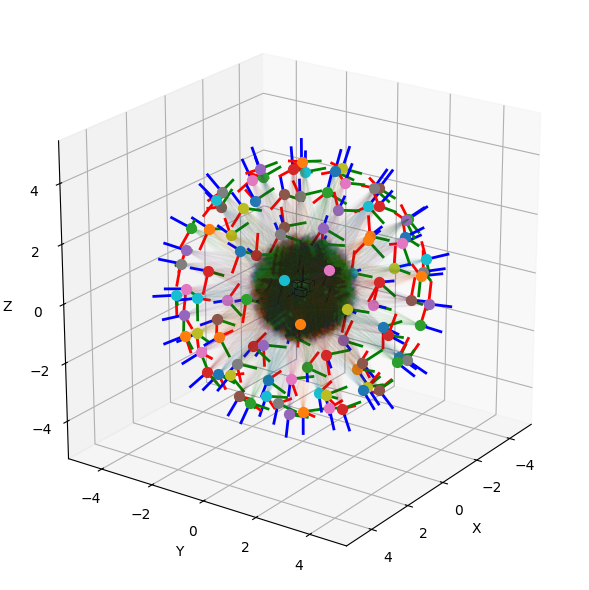

In [6]:
# 1) Single batched camera, draw 1k rays/pose and samples
plot_world(
    world,
    cameras=cam_batched,
    cam_indices="all",
    draw_rays=True, ray_mode="lines", rays_per_pose=100,
    draw_samples=True, samples_deterministic=True, ray_alpha=0.01, samples_alpha=0.002, shape_edge_alpha=1, shape_face_alpha= 1, set_labels=False
)

